# NY TLC Data exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# changing describe()-Function display format
pd.set_option("display.float_format", "{:.2f}".format)
df = pd.read_parquet("fhvhv_tripdata_2025-07.parquet")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19653012 entries, 0 to 19653011
Data columns (total 25 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     object        
 1   dispatching_base_num  object        
 2   originating_base_num  object        
 3   request_datetime      datetime64[us]
 4   on_scene_datetime     datetime64[us]
 5   pickup_datetime       datetime64[us]
 6   dropoff_datetime      datetime64[us]
 7   PULocationID          int32         
 8   DOLocationID          int32         
 9   trip_miles            float64       
 10  trip_time             int64         
 11  base_passenger_fare   float64       
 12  tolls                 float64       
 13  bcf                   float64       
 14  sales_tax             float64       
 15  congestion_surcharge  float64       
 16  airport_fee           float64       
 17  tips                  float64       
 18  driver_pay            float64       
 19

## Mapping Provider ID's to actual provider names

In [ ]:
mapping = {
    "HV0002": "Juno",
    "HV0003": "Uber",
    "HV0004": "Via",
    "HV0005": "Lyft"
}

df["hvfhs_license_num"] = df["hvfhs_license_num"].replace(mapping)

In [ ]:
df = df.rename(columns={
    "hvfhs_license_num": "Providers",
})

## Removing redundant data columns

In [ ]:
df.drop(["dispatching_base_num","originating_base_num"], axis = 1)

,Providers,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,Uber,2025-07-01 00:05:56,2025-07-01 00:08:03,2025-07-01 00:08:44,2025-07-01 00:28:42,65,179,9.93,1198,26.22,...,0.00,0.00,0.00,26.11,N,N,N,N,N,0.00
1,Lyft,2025-07-01 00:09:38,2025-07-01 00:16:28,2025-07-01 00:17:28,2025-07-01 00:22:50,35,35,0.79,322,6.27,...,0.00,0.00,0.00,4.39,N,N,N,N,N,0.00
2,Uber,2025-07-01 00:47:47,2025-07-01 00:51:20,2025-07-01 00:51:20,2025-07-01 01:04:56,233,143,3.05,816,21.76,...,2.75,0.00,0.00,12.53,N,N,N,N,N,1.50
3,Lyft,2025-07-01 00:05:36,2025-07-01 00:08:46,2025-07-01 00:09:18,2025-07-01 00:28:44,68,145,3.99,1166,23.03,...,2.75,0.00,0.00,19.06,N,N,N,N,Y,1.50
4,Lyft,2025-07-01 00:10:04,2025-07-01 00:35:56,2025-07-01 00:35:58,2025-07-01 01:09:06,132,90,17.70,1988,51.93,...,2.75,2.50,0.00,45.22,N,N,N,N,N,1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19653007,Uber,2025-07-31 23:02:22,2025-07-31 23:04:40,2025-07-31 23:05:33,2025-07-31 23:47:03,148,265,25.36,2490,175.34,...,0.00,0.00,0.00,95.01,N,N,N,N,N,1.50
19653008,Uber,2025-07-31 23:27:49,2025-07-31 23:35:37,2025-07-31 23:37:38,2025-08-01 00:38:36,249,221,16.52,3658,101.56,...,2.75,0.00,0.00,74.90,N,N,N,N,N,1.50
19653009,Uber,2025-07-31 23:37:00,2025-07-31 23:38:40,2025-07-31 23:39:30,2025-08-01 00:29:11,138,265,34.12,2980,134.47,...,0.00,2.50,0.00,82.57,N,N,N,N,N,0.00
19653010,Uber,2025-07-31 23:33:15,2025-07-31 23:39:39,2025-07-31 23:40:10,2025-07-31 23:52:48,145,140,3.61,757,9.90,...,0.75,0.00,0.00,8.73,Y,Y,N,N,N,0.00


## Remove invalid numerical entries

In [ ]:
df = df[df['trip_miles'] > 0]
df = df[df['base_passenger_fare'] > 0]
df = df[df['driver_pay'] > 0]

In [ ]:
df.describe()

,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee
count,19632115,19632115,19632115,19632115,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00,19632115.00
mean,2025-07-16 20:40:44.695115,2025-07-16 20:44:24.194698,2025-07-16 20:45:18.680252,2025-07-16 21:05:07.267994,137.78,141.94,5.11,1188.57,26.59,1.10,0.67,2.21,0.96,0.22,1.17,20.74,0.51
min,2025-06-30 23:17:00,2025-06-30 22:30:16,2025-07-01 00:00:00,2025-07-01 00:02:29,2.00,1.00,0.00,1.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00
25%,2025-07-09 11:23:39,2025-07-09 11:26:13,2025-07-09 11:27:13,2025-07-09 11:48:16.500000,75.00,75.00,1.58,596.00,12.19,0.00,0.29,1.00,0.00,0.00,0.00,9.10,0.00
50%,2025-07-16 23:05:06,2025-07-16 23:09:10,2025-07-16 23:09:55,2025-07-16 23:29:11,138.00,140.00,3.07,967.00,19.00,0.00,0.47,1.60,0.00,0.00,0.00,15.43,0.00
75%,2025-07-24 16:44:41,2025-07-24 16:47:58,2025-07-24 16:48:51,2025-07-24 17:14:14,207.00,216.00,6.43,1527.00,31.63,0.00,0.79,2.70,2.75,0.00,0.00,26.15,1.50
max,2025-08-01 00:03:23,2025-07-31 23:59:56,2025-07-31 23:59:59,2025-08-01 04:14:23,265.00,265.00,450.59,35554.00,2215.64,80.20,55.39,126.11,5.50,7.50,250.39,1579.08,3.00
std,NaN,NaN,NaN,NaN,74.68,77.99,6.02,858.11,24.87,3.59,0.65,2.04,1.30,0.72,3.56,18.46,0.71


## Visualisation of interesting datacolumns

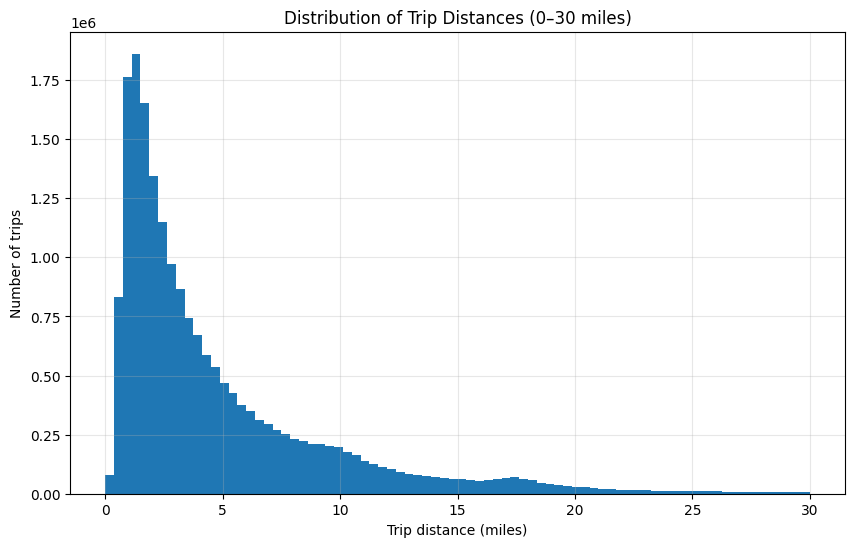

In [ ]:
plt.figure(figsize=(10, 6))

df.trip_miles.hist(bins=80, range=(0, 30))

plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.title("Distribution of Trip Distances (0–30 miles)")
plt.grid(alpha=0.3)

plt.show()

## Counting handicapped vehicle requests vs. matched rides

In [ ]:
df['wav_request_flag'].value_counts()

wav_request_flag
N    19567869
Y       64246
Name: count, dtype: int64

In [ ]:
df['wav_match_flag'].value_counts()

wav_match_flag
N    17963299
Y     1668816
Name: count, dtype: int64

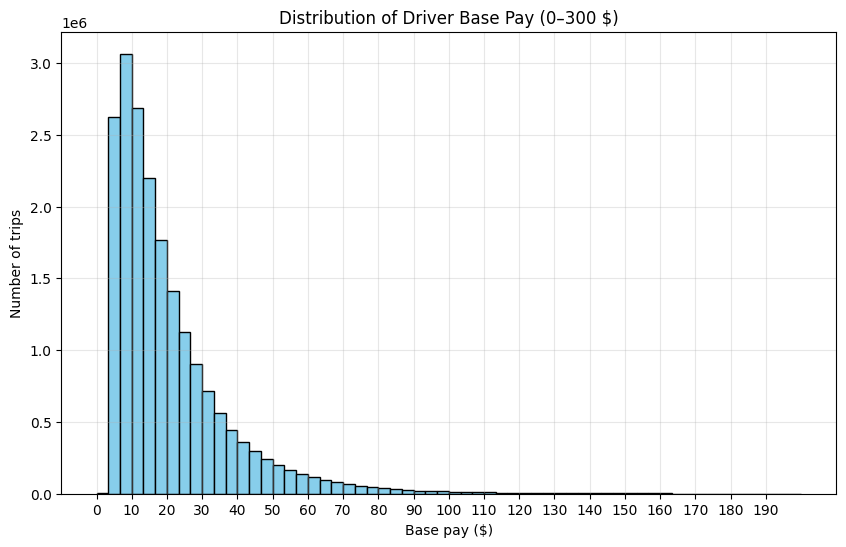

In [ ]:
plt.figure(figsize=(10, 6))

df.driver_pay.plot(
    kind="hist",
    bins=60,
    range=(0, 200),
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Base pay ($)")
plt.ylabel("Number of trips")
plt.title("Distribution of Driver Base Pay (0–300 $)")
plt.grid(alpha=0.3)

plt.xticks(np.arange(0, 200, 10))

plt.show()

## Comparing normal trips with wheelchair accessibility trips

In [ ]:
df_wac = df.copy()

df_wac['pickup_datetime'] = pd.to_datetime(df_wac['pickup_datetime'])
df_wac['request_datetime'] = pd.to_datetime(df_wac['request_datetime'])

wait_seconds = (df_wac['pickup_datetime'] - df_wac['request_datetime']).dt.total_seconds()

is_wav = df_wac['wav_request_flag'].eq('Y')

fare = df_wac['base_passenger_fare'].to_numpy()
wait_arr = wait_seconds.to_numpy()

wav_fare_mean = np.nanmean(fare[is_wav])
nonwav_fare_mean = np.nanmean(fare[~is_wav])

wav_wait_mean = np.nanmean(wait_arr[is_wav])
nonwav_wait_mean = np.nanmean(wait_arr[~is_wav])

print(f"Average fare (WAV):       ${wav_fare_mean:.2f}")
print(f"Average fare (non-WAV):   ${nonwav_fare_mean:.2f}")
print(f"Average wait (WAV):       {wav_wait_mean:.1f} sec")
print(f"Average wait (non-WAV):   {nonwav_wait_mean:.1f} sec")
print()
print(f"WAV fares are higher by {wav_fare_mean - nonwav_fare_mean:.2f}")
print(f"WAV waits are longer by {(wav_wait_mean - nonwav_wait_mean)/60:.1f} minutes")

Average fare (WAV):       $24.33
Average fare (non-WAV):   $26.60
Average wait (WAV):       318.8 sec
Average wait (non-WAV):   273.8 sec

WAV fares are higher by -2.27
WAV waits are longer by 0.7 minutes


## Drop rows with code 264 and 265 indicating unknown districts or trips outside of New York City

In [ ]:
df = df[~df['PULocationID'].isin([264, 265])]
df = df[~df['DOLocationID'].isin([264, 265])]

## Drop rows with a trip distance over 60 miles

In [ ]:
df = df[df['trip_miles'] <= 60]

/Users/jose/Desktop/Studium/DataEngineering/DataEngineering8/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


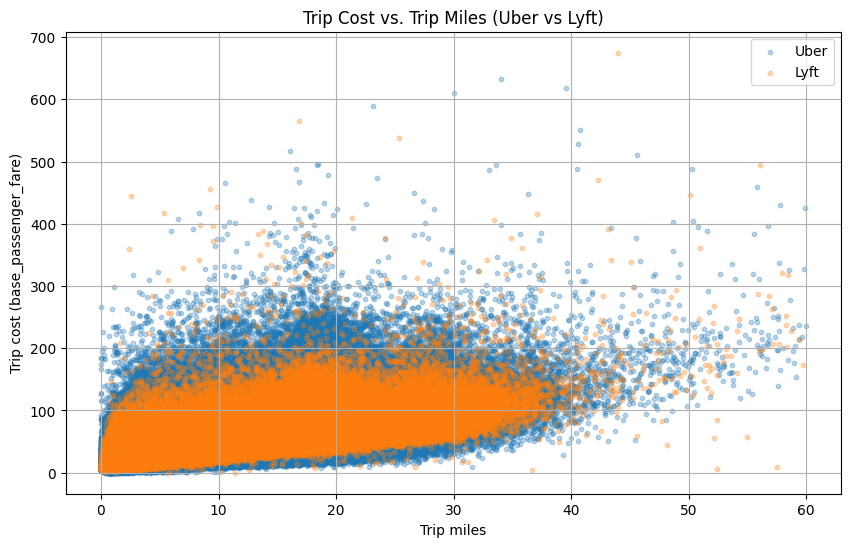

In [ ]:
plt.figure(figsize=(10,6))
for provider in ['Uber', 'Lyft']:
    subset = df[df['Providers'] == provider]
    plt.scatter(
        subset['trip_miles'],
        subset['base_passenger_fare'],
        alpha=0.3,
        label=provider,
        s=10
    )

plt.xlabel("Trip miles")
plt.ylabel("Trip cost (base_passenger_fare)")
plt.title("Trip Cost vs. Trip Miles (Uber vs Lyft)")
plt.legend()
plt.grid(True)
plt.show()

## Composition of extra charges in the total price

In [ ]:
fare_col = "base_passenger_fare"
extra_cols = [
    "tolls",
    "bcf",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "airport_fee"
]

tip_col = "tips"

cols = [fare_col] + extra_cols + [tip_col]

avg_components = df.groupby("Providers")[cols].mean()

avg_components["extra_charges"] = avg_components[extra_cols].sum(axis=1)
avg_components["tips"] = avg_components[tip_col]
avg_components["grand_total"] = avg_components[[fare_col, "extra_charges", "tips"]].sum(axis=1)

shares = avg_components.div(avg_components["grand_total"], axis=0) * 100
shares = shares[[fare_col, "extra_charges", "tips"]]

print("=== Average dollar amounts ===")
print(avg_components[[fare_col, "extra_charges", "tips", "grand_total"]])

print("\n=== Percentage of total bill (%) ===")
print(shares)

=== Average dollar amounts ===
           base_passenger_fare  extra_charges  tips  grand_total
Providers                                                       
Lyft                     23.17           2.94  1.14        27.25
Uber                     24.88           3.07  1.01        28.96

=== Percentage of total bill (%) ===
           base_passenger_fare  extra_charges  tips
Providers                                          
Lyft                     85.04          10.78  4.18
Uber                     85.90          10.60  3.50


test